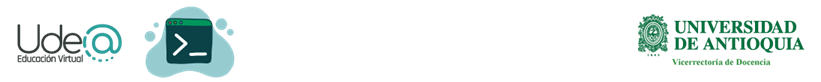

# <h1><center>Deploying Machine Learning Models with FastAPI and Ngrok: A Hands-On Guide</center></h1>

**Especialización en Analítica de Datos**

*Prof. Hernán Felipe García Arias*

*Facultad de Ingeniería*

*Universidad de Antioquia*


**2025-1**


Create an account at https://ngrok.com/

<hr>
<h2>🚀 Introduction to FastAPI Architecture</h2>

<p>
FastAPI is a modern, high-performance web framework for building APIs with Python. The above architecture represents a complete API system using FastAPI with a structured backend that integrates with a database.
</p>

<h3>🔹 Understanding the Architecture</h3>

<p>The architecture consists of multiple interconnected layers:</p>

<ul>
  <li><b>Client:</b> A user (or an application) that sends HTTP requests (GET, POST) to the server.</li>
  <li><b>Web Server:</b> A server (running <b>Uvicorn</b>) that hosts the FastAPI application and serves requests.</li>
  <li><b>Routing Logic (REST API):</b> Defines the API endpoints (GET, POST) in <code>main.py</code> to handle incoming HTTP requests.</li>
  <li><b>Pydantic Model (schema.py):</b> Data validation using <b>Pydantic</b> models that define structured request and response formats.</li>
  <li><b>SQLAlchemy ORM (model.py):</b> Defines the database structure using SQLAlchemy ORM models (User, Topic, Post, Response).</li>
  <li><b>Database Engine (database.py):</b> Manages the connection to a relational database (e.g., MySQL) through an ORM session.</li>
</ul>

<h3>🔹 Workflow</h3>
<ol>
  <li>The <b>Client</b> sends an API request (GET or POST) to <code>http://localhost:8000</code>.</li>
  <li>The request is processed by the <b>Web Server</b> (Uvicorn), which forwards it to FastAPI.</li>
  <li>The <b>Routing Logic</b> in <code>main.py</code> directs the request to the correct endpoint.</li>
  <li>Data validation is handled using the <b>Pydantic Model</b> in <code>schema.py</code>.</li>
  <li>The request interacts with the database through <b>SQLAlchemy ORM</b> in <code>model.py</code>.</li>
  <li>The <b>Database Engine</b> in <code>database.py</code> manages the database connection.</li>
  <li>The API sends back a structured JSON response to the client.</li>
</ol>

<h3>🔹 Why This Matters?</h3>
<ul>
  <li>Ensures a <b>structured and scalable</b> approach for API development.</li>
  <li>Provides <b>data validation</b> using Pydantic.</li>
  <li>Allows easy <b>database management</b> with SQLAlchemy.</li>
  <li>Enables efficient <b>REST API implementation</b> with FastAPI.</li>
</ul>

<p>💡 <b>In this notebook</b>, we will implement this architecture to deploy a Machine Learning API using FastAPI and Ngrok.</p>

<hr>


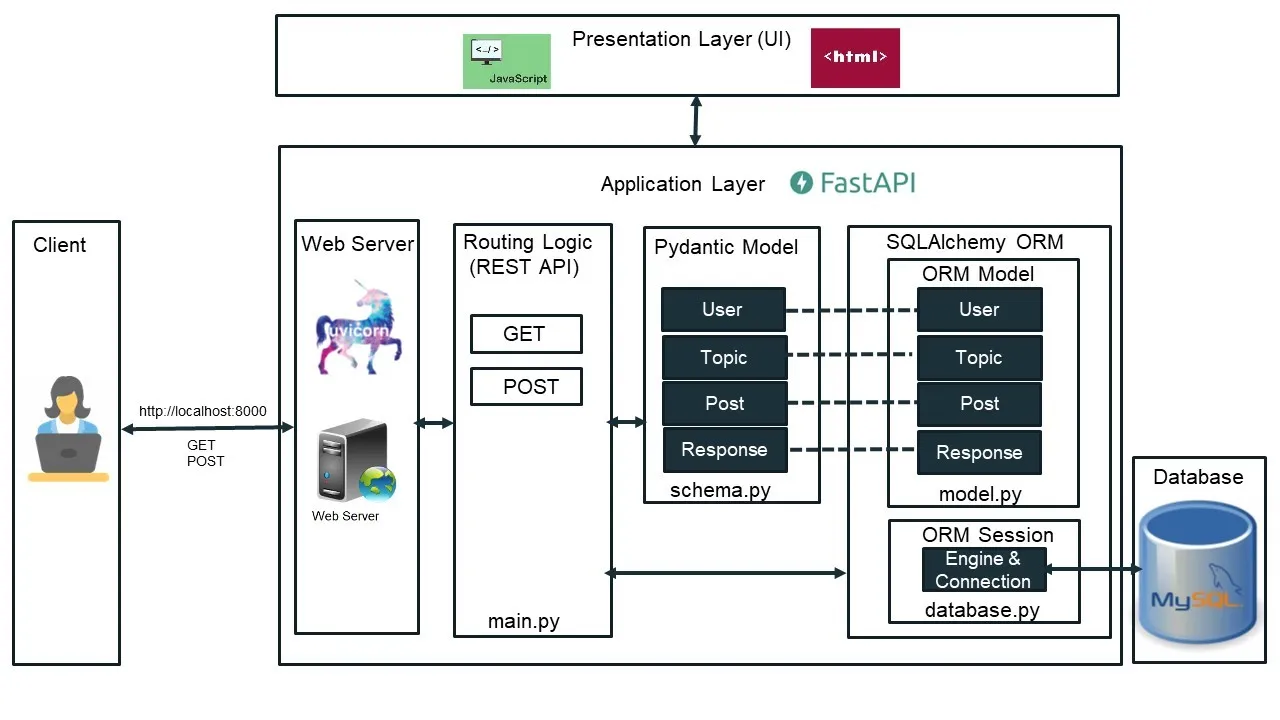

In [ ]:
# Install necessary packages
!pip install fastapi uvicorn scikit-learn joblib nest-asyncio xgboost umap-learn
# Generate public URL with ngrok
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.5 MB/s eta 0:00:00


In [ ]:


# Import required libraries
import joblib
import numpy as np
import nest_asyncio
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import xgboost as xgb
import umap



<h2>🔍 Clustering Mall Customers Using K-Means</h2>

<hr>

<h3>📌 Introduction</h3>

<p>
In this tutorial, we will apply <b>K-Means clustering</b> to segment customers based on their purchasing behavior.
Clustering is an unsupervised learning technique that groups similar data points together based on their features.
This technique is widely used in marketing and business analytics to identify customer segments.
</p>

<h3>📝 Dataset Description</h3>

<p>
The dataset contains information about customers in a shopping mall, including:
</p>

<ul>
    <li><b>Annual Income (k$)</b>: The yearly income of the customer.</li>
    <li><b>Spending Score (1-100)</b>: A measure of customer spending habits.</li>
</ul>

<p>
By clustering customers based on these two features, we aim to identify different groups that share similar purchasing behavior.
</p>

<h3>⚙️ Preprocessing Steps</h3>

<p>
To prepare the dataset for clustering, we follow these steps:
</p>

<ul>
    <li>📌 Select relevant features: <code>Annual Income</code> and <code>Spending Score</code>.</li>
    <li>📌 Standardize the data using <b>StandardScaler</b> to normalize feature scales.</li>
    <li>📌 Train a <b>K-Means model</b> with <code>n_clusters = 5</code> to identify 5 customer segments.</li>
</ul>

<h3>📊 K-Means Clustering</h3>

<p>
The <b>K-Means algorithm</b> works as follows:
</p>

<ol>
    <li>📍 Select <b>k</b> random cluster centroids.</li>
    <li>📍 Assign each data point to the nearest cluster centroid.</li>
    <li>📍 Recalculate the centroids by averaging all points in a cluster.</li>
    <li>📍 Repeat until centroids stabilize (convergence).</li>
</ol>

<p>
Once the model is trained, we assign a cluster label to each customer.
This segmentation can help businesses target specific groups for marketing campaigns.
</p>

<h3>📂 Model Saving</h3>

<p>
After training, we save the <b>K-Means model</b> and the <b>scaler</b> to reuse them later in a FastAPI deployment.
</p>

<hr>

<h3>✅ Next Steps</h3>

<p>
Now that we have successfully clustered the customers, we will deploy this model as a <b>Machine Learning API</b> using <b>FastAPI</b> and expose it using <b>Ngrok</b>.
This will allow us to make predictions on new customer data via API requests.
</p>



In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
url = "FIFA23_official_data.csv"
df = pd.read_csv(url)
df.head(3)

,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,Club Logo,...,Real Face,Position,Joined,Loaned From,Contract Valid Until,Height,Weight,Release Clause,Kit Number,Best Overall Rating
0,209658,L. Goretzka,27,https://cdn.sofifa.net/players/209/658/23_60.png,Germany,https://cdn.sofifa.net/flags/de.png,87,88,FC Bayern München,https://cdn.sofifa.net/teams/21/30.png,...,Yes,"<span class=""pos pos28"">SUB","Jul 1, 2018",NaN,2026,189cm,82kg,€157M,8.0,NaN
1,212198,Bruno Fernandes,27,https://cdn.sofifa.net/players/212/198/23_60.png,Portugal,https://cdn.sofifa.net/flags/pt.png,86,87,Manchester United,https://cdn.sofifa.net/teams/11/30.png,...,Yes,"<span class=""pos pos15"">LCM","Jan 30, 2020",NaN,2026,179cm,69kg,€155M,8.0,NaN
2,224334,M. Acuña,30,https://cdn.sofifa.net/players/224/334/23_60.png,Argentina,https://cdn.sofifa.net/flags/ar.png,85,85,Sevilla FC,https://cdn.sofifa.net/teams/481/30.png,...,No,"<span class=""pos pos7"">LB","Sep 14, 2020",NaN,2024,172cm,69kg,€97.7M,19.0,NaN


In [ ]:
# Funciones
def convert_mk_to_numeric(value):
    if isinstance(value, str):  # Asegurar que el valor es una cadena
        if 'M' in value:
            return float(value.replace('M', '')) * 1e6
        elif 'K' in value:
            return float(value.replace('K', '')) * 1e3
        else:
            return float(value)
    return value  # Si no es string, devolver el valor original

def convert_height_to_numeric(height):
    if isinstance(height, str):  # Asegurar que el valor es una cadena
        return float(height.replace('cm', ''))
    return height  # Si no es string, devolver el valor original

def convert_weight_to_numeric(weight):
    if isinstance(weight, str):  # Asegurar que el valor es una cadena
        return float(weight.replace('kg', ''))
    return weight  # Si no es string, devolver el valor original

In [ ]:
# Cambio de tipo de datos a numerico
# Columna Value
df['Value'] = df['Value'].str[1:]
df['Value']= df['Value'].apply(convert_mk_to_numeric)

# Columna Wage
df['Wage'] = df['Wage'].str[1:]
df['Wage'] = df['Wage'].apply(convert_mk_to_numeric)

In [ ]:
df2 = df[['Age', 'Value', 'Wage']]

In [ ]:
df[['Age', 'Value', 'Wage']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17660 entries, 0 to 17659
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     17660 non-null  int64  
 1   Value   17660 non-null  float64
 2   Wage    17660 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 414.0 KB


In [ ]:
X = df2
X

,Age,Value,Wage
0,27,91000000.0,115000.0
1,27,78500000.0,190000.0
2,30,46500000.0,46000.0
3,31,107500000.0,350000.0
4,25,89500000.0,110000.0
...,...,...,...
17655,19,100000.0,500.0
17656,17,100000.0,500.0
17657,25,70000.0,2000.0
17658,18,90000.0,500.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
url = "FIFA23_official_data.csv"
df = pd.read_csv(url)

# Preprocess dataset (select relevant features for clustering)
X = df2

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train a K-Means clustering model
n_clusters = 5  # Define number of clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Save the trained model and scaler
import pickle
pickle.dump(kmeans, open("kmeans_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("✅ Model trained and saved successfully!")


✅ Model trained and saved successfully!


<hr>

<h3>🚀 FastAPI Clustering API Deployment</h3>

<p>This section explains the FastAPI implementation for deploying a <b>clustering model</b> trained on the <i>Mall Customer dataset</i>. The API allows users to input customer attributes and receive both a <b>predicted cluster</b> and a <b>ranking interpretation</b>.</p>

<hr>

<h3>📂 Loading the Trained Model</h3>

<p>The API loads a pre-trained <b>K-Means clustering model</b> and <b>StandardScaler</b> to preprocess customer data:</p>

<pre>
# Load the saved model and scaler
kmeans = pickle.load(open("kmeans_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
</pre>

<p>This ensures that the model can process new data without retraining.</p>

<hr>

<h3>🛠️ FastAPI Application Initialization</h3>

<p>The API is built using <b>FastAPI</b>, a lightweight framework for serving ML models:</p>

<pre>
app = FastAPI()
</pre>

<p>FastAPI enables quick deployment with built-in support for <b>Swagger UI</b> and <b>automatic request validation</b>.</p>

<hr>

<h3>📌 Defining the Request Schema</h3>

<p>To standardize input data, a request schema is defined using <b>Pydantic</b>:</p>

<pre>
class CustomerData(BaseModel):
    annual_income: float
    spending_score: float
</pre>

<p>This ensures that any incoming request must contain valid numerical values for <i>Annual Income</i> and <i>Spending Score</i>.</p>

<hr>

<h3>🌐 Root Endpoint (`GET /`)</h3>

<p>The root endpoint verifies that the API is running:</p>

<pre>
@app.get("/")
def home():
    return {"message": "Mall Customer Clustering API is running!"}
</pre>

<p>Accessing this endpoint returns a JSON message confirming that the API is operational.</p>

<hr>

<h3>📊 Predicting Customer Clusters (`POST /predict/`)</h3>

<p>The main function of the API is to receive customer data and classify it into one of <b>five clusters</b>. The prediction workflow includes:</p>

<ul>
    <li>Extracting input features (<i>Annual Income</i>, <i>Spending Score</i>).</li>
    <li>Scaling the input using the preloaded <b>StandardScaler</b>.</li>
    <li>Using the trained <b>K-Means model</b> to assign a cluster.</li>
    <li>Mapping the cluster to a human-readable <b>customer ranking</b>.</li>
</ul>

<pre>
@app.post("/predict/")
def predict_cluster(data: CustomerData):
    input_data = np.array([[data.annual_income, data.spending_score]])
    input_scaled = scaler.transform(input_data)
    cluster = kmeans.predict(input_scaled)[0]

    ranking = get_ranking(cluster)

    return {"Cluster": int(cluster), "Customer_Ranking": ranking}
</pre>

<p>The response returns both the assigned <b>cluster</b> and a descriptive <b>customer ranking</b>.</p>

<hr>

<h3>🏆 Customer Ranking System</h3>

<p>The function <code>get_ranking()</code> assigns meaningful labels to each cluster:</p>

<pre>
def get_ranking(cluster):
    rankings = {
        0: "Low-Value Customer",
        1: "Occasional Shopper",
        2: "Loyal Customer",
        3: "High-Spending Regular",
        4: "VIP Customer"
    }
    return rankings.get(cluster, "Unknown Cluster")
</pre>

<p>For example:</p>
<ul>
    <li><b>Cluster 0:</b> "Low-Value Customer" (low spending, low visits).</li>
    <li><b>Cluster 4:</b> "VIP Customer" (high spending, frequent visits).</li>
</ul>

<hr>

<h3>🔗 Exposing the API with Ngrok</h3>

<p>Since Google Colab does not allow direct API access, <b>Ngrok</b> is used to create a temporary public URL:</p>

<pre>
!ngrok config add-authtoken YOUR_AUTH_TOKEN
public_url = ngrok.connect(port).public_url
print(f"🔗 Public API URL: {public_url}")
</pre>

<p>After execution, you will see an output like:</p>
<pre>
🔗 Public API URL: https://xxxx.ngrok-free.app
</pre>

<p>You can access the API documentation at:</p>
<pre>
https://xxxx.ngrok-free.app/docs
</pre>

<hr>

<h3>🚀 Starting the FastAPI Server</h3>

<p>The API runs in a separate thread using <b>Uvicorn</b>:</p>

<pre>
def run():
    uvicorn.run(app, host="0.0.0.0", port=port)

threading.Thread(target=run).start()
</pre>

<p>This ensures that the API remains active while executing in a <b>Google Colab notebook</b>.</p>

<hr>

<h3>📢 Testing the API</h3>

<p>To test the API, use:</p>
<ul>
    <li>Swagger UI at: <code>https://xxxx.ngrok-free.app/docs</code></li>
    <li>Postman or cURL:</li>
</ul>

<pre>
curl -X 'POST' \
  'https://xxxx.ngrok-free.app/predict/' \
  -H 'accept: application/json' \
  -H 'Content-Type: application/json' \
  -d '{
    "annual_income": 50,
    "spending_score": 80
}'
</pre>

<p><b>Expected Response:</b></p>
<pre>
{
  "Cluster": 3,
  "Customer_Ranking": "High-Spending Regular"
}
</pre>

<hr>

<h3>🎯 Summary</h3>

<p>This tutorial covered:</p>
<ul>
    <li>Deploying a trained K-Means clustering model with FastAPI.</li>
    <li>Standardizing input data and predicting clusters.</li>
    <li>Assigning meaningful customer rankings based on clusters.</li>
    <li>Exposing the API using Ngrok for external access.</li>
</ul>

<p>🔹 <b>Next Steps:</b> Try modifying the model by adding new features like <i>Age</i> or experimenting with different numbers of clusters!</p>

<hr>


In [ ]:
import uvicorn
import threading
import pickle
from fastapi import FastAPI
from pydantic import BaseModel
from pyngrok import ngrok

# Load the saved model and scaler
kmeans = pickle.load(open("kmeans_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

# Initialize FastAPI application
app = FastAPI()

# Define request schema
class CustomerData(BaseModel):
    Age: int
    Value: float
    Wage: float

# Define the root endpoint
@app.get("/")
def home():
    return {"message": "Sistema de seleccion de troncos!"}



def get_ranking(cluster):
    rankings = {
        0: "Muy malo",
        1: "Malo",
        2: "Regular",
        3: "Bueno",
        4: "Muy bueno"
    }
    return rankings.get(cluster, "Unknown Cluster")

    # Define clustering endpoint
@app.post("/predict/")
def predict_cluster(data: CustomerData):
    input_data = np.array([[data.Age, data.Value, data.Wage]])
    input_scaled = scaler.transform(input_data)
    cluster = kmeans.predict(input_scaled)[0]

    ranking = get_ranking(cluster)  # Make sure this line exists

    return {"Cluster": int(cluster), "Customer_Ranking": ranking}


# Expose the API with ngrok
port = 8000
!ngrok config add-authtoken TOKEN-NUMBER
public_url = ngrok.connect(port).public_url
print(f"🔗 Public API URL: {public_url}")

# Start the FastAPI server in a new thread
def run():
    uvicorn.run(app, host="0.0.0.0", port=port)

threading.Thread(target=run).start()


Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml
🔗 Public API URL: https://5a06-34-170-180-105.ngrok-free.app


<hr>

<h2>📌 Understanding GET, POST, and Schemas in FastAPI</h2>

<p>When deploying a Machine Learning (ML) model using <b>FastAPI</b>, it is essential to understand how the API interacts with the client via <b>GET</b> and <b>POST</b> requests. In this section, we describe these components in detail and their role in the clustering model deployment.</p>

<hr>

<h3>🔹 1. GET Requests</h3>

<p><b>Definition:</b> The <code>GET</code> method is used to retrieve information from the server without modifying any data.</p>

<p>In our API, the following endpoint is defined:</p>

<pre><code>GET /</code></pre>

<p><b>Function:</b> This endpoint returns a simple confirmation message that the API is running. When a client sends a request to this endpoint, the response is:</p>

<pre><code>{
  "message": "Mall Customer Clustering API is running!"
}</code></pre>

<p>This ensures that the FastAPI server is active and ready to process requests.</p>

<hr>

<h3>🔹 2. POST Requests</h3>

<p><b>Definition:</b> The <code>POST</code> method is used to send data to the server for processing. Unlike <code>GET</code>, a <code>POST</code> request modifies the system state by submitting input data and receiving a response.</p>

<p>In our API, the following endpoint handles clustering predictions:</p>

<pre><code>POST /predict/</code></pre>

<h4>🔸 How It Works:</h4>

<p>This endpoint receives customer data (e.g., annual income and spending score), processes it using a pre-trained <b>K-Means</b> clustering model, and returns the predicted cluster.</p>

<h4>🔸 Example Input (JSON format):</h4>

<pre><code>{
  "annual_income": 50,
  "spending_score": 80
}</code></pre>

<h4>🔸 Expected Output:</h4>

<pre><code>{
  "Cluster": 2
}</code></pre>

<p>The model assigns this customer to <b>Cluster 2</b>, which represents a specific behavioral group based on the given features.</p>

<hr>

<h3>🔹 3. Schemas in FastAPI</h3>

<p><b>Definition:</b> A <i>schema</i> defines the structure of data expected in a request. In FastAPI, schemas are created using <code>Pydantic</code> models, which enforce type validation.</p>

<p>Our API defines a schema named <code>CustomerData</code>, which specifies that the <code>POST /predict/</code> request must include:</p>

<ul>
  <li><b>annual_income</b>: A floating-point number representing the customer's annual income.</li>
  <li><b>spending_score</b>: A floating-point number representing the spending behavior of the customer.</li>
</ul>

<p>The schema ensures that only correctly formatted data is processed by the clustering model.</p>

<hr>

<h3>📌 Open Swagger UI for API Testing</h3>

<p>Swagger UI provides an interactive interface to test API endpoints directly from the browser. You can open Swagger UI at:</p>

<pre><code>
🔗 <a href="https://0aa2-34-86-205-247.ngrok-free.app/docs" target="_blank">
https://0aa2-34-86-205-247.ngrok-free.app/docs
</a>
</code></pre>

<p>Once the page is open, you can:</p>

<ul>
  <li>Explore all available API endpoints.</li>
  <li>Send requests and observe the responses.</li>
  <li>Test the <code>POST /predict/</code> endpoint by entering sample customer data.</li>
</ul>

<hr>

<h3>📌 Summary of API Methods</h3>

<table border="1" cellspacing="0" cellpadding="5">
  <tr>
    <th>HTTP Method</th>
    <th>Function</th>
    <th>Example</th>
  </tr>
  <tr>
    <td><b>GET</b> <code>/</code></td>
    <td>Returns a confirmation that the API is running</td>
    <td><pre><code>{"message": "Mall Customer Clustering API is running!"}</code></pre></td>
  </tr>
  <tr>
    <td><b>POST</b> <code>/predict/</code></td>
    <td>Receives customer data and predicts a cluster</td>
    <td><pre><code>{"Cluster": 2}</code></pre></td>
  </tr>
  <tr>
    <td><b>Schemas</b></td>
    <td>Defines required data format for requests</td>
    <td><pre><code>{"annual_income": 50, "spending_score": 80}</code></pre></td>
  </tr>
</table>

<hr>

<h3>📌 Summary</h3>

<p>In this tutorial, we have demonstrated how to build a FastAPI-based Machine Learning service for clustering customers based on their spending habits. The API follows a structured design with:</p>

<ul>
  <li>A <b>GET</b> request for system health checking.</li>
  <li>A <b>POST</b> request to submit data and receive clustering predictions.</li>
  <li>A schema definition ensuring correct data formatting.</li>
  <li>An interactive <b>Swagger UI</b> for testing and validation.</li>
</ul>

<p>Such an architecture enables efficient integration of clustering models in production-ready applications.</p>

<hr>


Once you visit

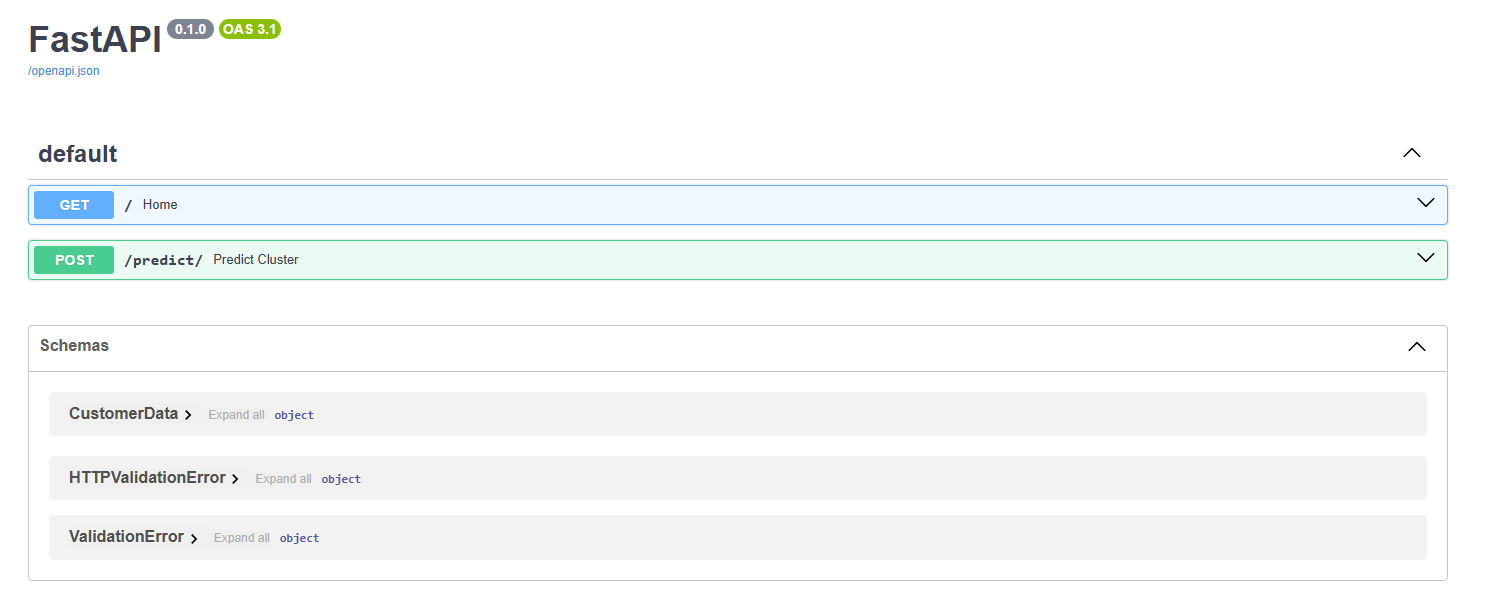

<hr>
<h3>🛠️ Final Project: Deploy Your Own ML API</h3>

<p>In this exercise, you will apply what you've learned by deploying your own ML model with FastAPI and Ngrok.</p>

<h4>🔹 Task:</h4>
<ul>
  <li>Choose a different dataset (e.g., <b>FIFA Players, Credit Card Fraud, or Titanic Survival, [Music Recommendation](https://www.kaggle.com/code/vatsalmavani/music-recommendation-system-using-spotify-dataset/input) </b>).</li>
  <li>Preprocess the data (use embeddings to enhace models) and train a <b>clustering or classification model</b> using any ML technique.</li>
  <li>Deploy your trained model with <b>FastAPI</b> in Google Colab.</li>
  <li>Use <b>Ngrok</b> to expose your API and test it with Swagger UI.</li>
</ul>

<h4>🔹 Deliverables:</h4>
<ul>
  <li>Submit a Jupyter Notebook (.ipynb) with the complete implementation.</li>
  <li>Include the <b>Ngrok public URL</b> for testing.</li>
  <li>Provide API documentation and test results using Swagger UI/Postman.</li>
</ul>

<h4>🔹 Questions to Reflect:</h4>
<ol>
  <li>What are the advantages of using Ngrok for quick API exposure?</li>
  <li>How would you improve the API security before deploying it in production?</li>
</ol>

